# Линейная регрессия

## Определение

Линейная регрессия — один из простейших алгоритмов машинного обучения, описывающий зависимость целевой переменной от признака в виде линейной функции

$y = kx + b$.

В данном случае была представлена ​​простая или парная линейная регрессия, а уравнение вида

$f_{w,b}(x) = w_0x_0 + w_1x_1+... + w_{n}x_{n} + b=w \cdot x + b$

называется множественной линейной регрессией, где $b$ — смещение для модели, $w$ — вектор ее весов, а $x$ — вектор признаков одной обучающей выборки.

Другие условия определения линейной регрессии включают гомоскедастичность (дисперсия остатков постоянна и конечна), а также отсутствие мультиколленарности (линейной зависимости между признаками).

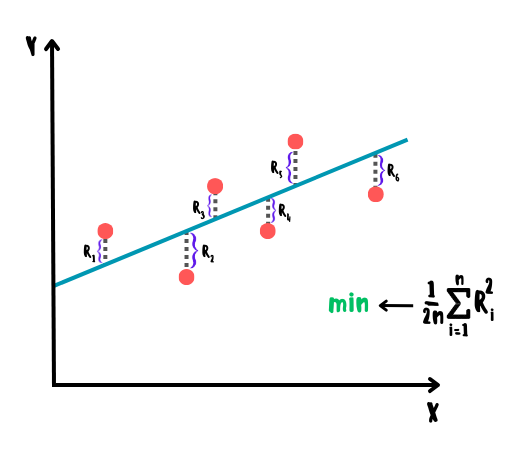

## **Метод наименьших квадратов и функция стоимости**
Выбор линии (плоскости) регрессии, наилучшим образом описывающей взаимосвязь данных, заключается в минимизации функции стоимости $J$, представленной в виде стандартной ошибки. Проще говоря, линия должна проходить по данным таким образом, чтобы в среднем разница между квадратами ожидаемых и реальных значений была минимальной. Этот метод называется методом наименьших квадратов.

При наличии большого количества выбросов в данных метод наименьших модулей может быть более эффективным, но у него есть один серьезный недостаток: функция модуля не дифференцируема в точке $x = 0$, что в некоторых случаях может затруднить минимизацию ошибки модели.

Таким образом, исходя из теоремы Маркова-Гаусса, метод наименьших квадратов является наиболее оптимальной оценкой параметров модели среди всех линейных и несмещенных оценок из-за меньшей дисперсии.

**Доказательство нормального уравнения (нормальное уравнение наименьших квадратов)**

$J(w, X, y) =
\frac{1}{2n} \sum\limits_{i = 1}^{n} (w^T x_i - y_i)^2 =
\frac{1}{2n} ||X w - y||^{2} =
\frac{1}{2n} (X w - y)^T (X w - y) = \\
= \frac{1}{2n} ((X w)^T X w - (X w)^T y - y^T X w + y^T y) = |(X w)^T y = y^T X w| = \\
= \frac{1}{2n} (w^T X^T X w - 2 y^T X w + y^T y)$

$\frac{\partial J}{\partial w} = 0 \ \ \Rightarrow \ \ \frac{1}{2n} (2X^TX w - 2X^T y) = 0 \ \ \Rightarrow \ \ X^TX w = X^T y
\ \ \Rightarrow \ \ w = (X^TX)^{-1} X^T y$

## **Принцип работы линейной регрессии**
Существует 2 основных способа обучения линейной регрессии:
- 1) Прямое (нормальное) уравнение в аналитической форме $w = (X^{T}X)^{-1}X^{T}y$, где в данном случае $w$ — вектор весов, включая смещение $b$. Основным недостатком этого метода является высокая вычислительная сложность при большом количестве признаков.
- 2) Итеративная оптимизация с постепенным уменьшением погрешности модели на основе градиентного спуска и его разновидностей. Этот метод чаще всего используется на практике.

**Линейная регрессия на основе градиентного спуска строится следующим образом**:
- 1) изначально задаются нулевые значения для весов, смещения и их градиентов;
- 2) на основе заданных значений делается прогноз;
- 3) на основе полученного прогноза пересчитываются значения весов и смещения, а также уменьшение их градиентов (разница значений в текущей и предыдущей итерациях);
- 4) шаги 2-3 повторяются до тех пор, пока уменьшение градиента не станет меньше заданного порогового значения;
- 5) итоговый прогноз будет представлять собой линейную комбинацию полученных весов + смещения и признаков в тестовой выборке.

## **Формулы для расчетов**

$\begin{align}
\frac{\partial J(\Theta)}{\partial b}  &= \frac{1}{n} \sum\limits_{i = 1}^{n} (f_{w ,b}(x_i) - y_i) \\
\frac{\partial J(\Theta)}{\partial w}  &= \frac{1}{n} \sum\limits_{i = 1}^{n} (f_{w ,b}(x_i) - y_i) x_i \\
\end{align}$

$\begin{align} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& b_j = b_{j-1} - \alpha \frac{\partial J(\Theta)}{\partial b_j} \\
& w_j = w_{j-1} - \alpha \frac{\partial J(\Theta)}{\partial w_j}
\newline \rbrace
\end{align}$

$\alpha$ — learning rate (скорость обучения)

$j$ — текущая итерация для смещения и весов

$\Theta$ — матрица параметров

## **Полиномиальная регрессия**
Линейную регрессию можно также применять к нелинейным данным, добавляя степени каждого признака в виде новых признаков с последующим обучением на полученном наборе данных. Такой подход позволяет фиксировать линейные связи в многомерном пространстве признаков и называется **полиномиальной регрессией**, а для преобразования признаков в полином степени n в scikit-learn есть класс PolynomialFeatures, который, помимо степеней каждого признака, добавляет их комбинации к заданной степени. Например, для признаков $a$ и $b$ со степенью 3, в дополнение к $a^2$, $a^3$ и $b^2$, $b^3$, их комбинации также будут добавлены в виде $ab$, $a^2b$ и $a b^2$.

Стоит отметить, что полиномиальная регрессия по-прежнему линейна, но на графике в исходном пространстве признаков она будет выглядеть как кривая, поскольку результирующая гиперплоскость в многомерном пространстве признаков будет соответствовать сложной кривой линии в исходном пространстве.

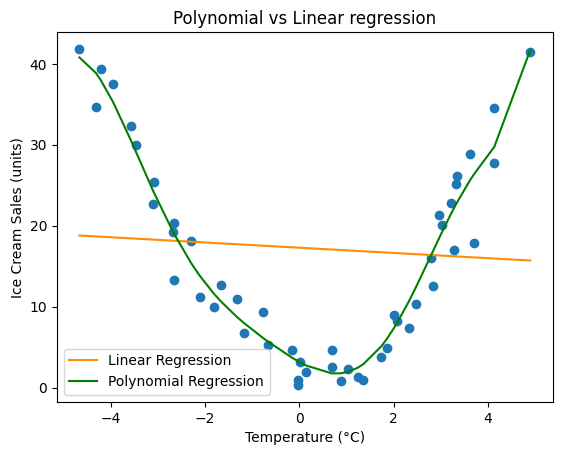

## **Регуляризация линейной регрессии (Ridge, Lasso, ElasticNet)**
Если в полиномиальной регрессии регуляризация позволяет уменьшить кривизну линии за счет уменьшения числа степеней полинома, то в случае линейной регрессии регуляризация будет заключаться в изменении наклона линии путем ограничения весов модели, обмена большего смещения на низкую дисперсию.

**Регрессия гребня** или *Ridge regression*, *регуляризация Тихонова* применяется в случае мультиколлинеарности путем добавления L2-регуляризации к функции стоимости во время обучения и больше всего занижает веса для признаков с высокой корреляцией: их значения будут приближаться к нулю, но никогда не достигнут его. Лучше всего применять регрессию гребня после стандартизации признаков.

$J += \alpha \sum \limits_{i=1}^{n} w_i^2$

**Лассо-регрессия (Lasso regression или Least Absolute Shrinkage & Selection Operator)** обычно используется для выбора признаков путем добавления L1-регуляризации к функции стоимости во время обучения. Проще говоря, лассо-регрессия стремится уменьшить количество параметров модели путем обнуления весов для неинформативных и избыточных признаков, что даст разреженную модель (с небольшим количеством ненулевых весов признаков).

$J += \alpha \sum \limits_{i=1}^{n} |w_i|$

**ElasticNet** представляет собой комбинацию L1- и L2-регуляризаций через отношение их смеси $r$, что может быть особенно полезно в ситуациях, когда необходимо одновременно выбирать признаки в данных и предотвращать мультиколлинеарность. В Scikit-Learn "l1_ratio" используется для управления смесью Ridge и Lasso.

$J = MSE(w) + r\alpha \sum \limits_{i=1}^{n} |w_i| +
\frac{1 - r}{2} \alpha \sum \limits_{i=1}^{n} w_i^2$

Кроме того, в качестве регуляризации линейной регрессии вы все еще можете использовать **раннюю остановку**, которая заключается в остановке обучения модели после определенного количества итераций или достижения заданного уровня ошибки в проверочных выборках. Однако при использовании стохастического или мини-пакетного градиентного спуска в этом случае может быть сложно найти минимальную ошибку из-за менее плавных кривых обучения.

Стоит также отметить, что вышеперечисленные методы регуляризации часто показывают хорошее увеличение точности на зашумленных данных, а в случае полиномиальных признаков можно добиться несколько меньшей кривизны линии, что также увеличит обобщающую способность модели.

## **Плюсы и минусы линейной регрессии**
Плюсы:
- простота реализации и интерпретации;
- высокая скорость работы;
- относительно хорошая точность в случае линейной зависимости в данных.

Минусы:
- низкая гибкость и адаптивность из-за предположения о линейности данных;
- низкая точность в случае сложных данных, что следует из предыдущего пункта;
- чувствительность к шуму и выбросам.

Стоит отметить, что перечисленные недостатки относятся к классическому случаю и могут быть частично или полностью устранены с помощью описанных выше методов. Однако на сегодняшний день существуют более стабильные и эффективные алгоритмы, используемые в классическом машинном обучении.

# Логистическая регрессия



## **Определение логистической регрессии**
Логистическая регрессия — это линейный бинарный классификатор, основанный на применении сигмоидной функции к линейной комбинации признаков, результатом которого является вероятность принадлежности к определенному классу. Обычно порог задается равным 0,5: если вероятность меньше порога, класс принадлежит 0, а если больше — 1. В принципе, условия определения логистической регрессии такие же, как и для линейной регрессии, за исключением целевой бинаризации.

Поскольку прогноз в линейной регрессии может принимать значения в любом диапазоне, а нам нужны вероятности принадлежности к классу в диапазоне [0; 1], прогноз линейной регрессии можно представить в виде логарифма шансов (шанс — отношение вероятности события к его невыполнению) и уже из него выразить вероятность принадлежности к классу. Полученная функция называется сигмоидой.

$\ln(\frac{p_+}{1 - p_+}) = w \cdot x + b$

$\frac{p_+}{1 - p_+} = e^{w \cdot x + b} \ \ \Rightarrow \ \ p_+ = \frac{1}{1 + e^{-(w \cdot x + b)}} = \sigma(w \cdot x + b)$

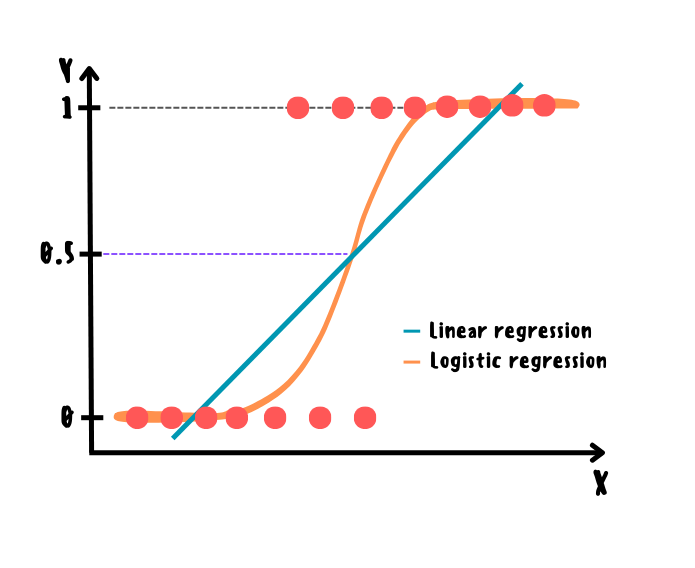

## **Функция стоимости и метод максимального правдоподобия**
Лучший способ выбора линии (плоскости) для разделения классов — минимизация средней логистической функции стоимости на основе оптимизации метода максимального правдоподобия. Суть этого метода заключается в поиске параметров модели, которые будут соответствовать наблюдениям с максимальной вероятностью, а его оптимизация заключается в логарифме правдоподобия вместо правдоподобия из-за вычислительной эффективности и более стабильных результатов. Проще говоря, функция стоимости — это просто средние потери по всему обучающему набору.

Поскольку в этом случае нет аналитического решения, а функция потерь гладкая и выпуклая, обучение логистической регрессии также происходит на основе градиентного спуска, как и в случае линейной регрессии.

## **Вывод уравнения логистической регрессии и градиента его функции стоимости**

$\begin{equation}
  L(\sigma(z), y_i) = \begin{cases}
    - \ln\sigma(z) & \text{if $y_i=1$}\\
    - \ln(1 - \sigma(z)) & \text{if $y_i=0$}
  \end{cases}
\end{equation} \ - \ $ initial form of the logistic loss

$L(\sigma(z), y_i) = \prod\limits_{i=1}^{n} σ(z)^{y_i} (1 - \sigma(z))^{(1-y_i)}
\ \ - \ $ maximum likelihood method

$L_{log}(\sigma(z), y_i) = -[y_i\ln\sigma(z) + (1 - y_i)\ln(1 - \sigma(z))]\ \ - \ $ logistic loss with likelihood logarithm

$J(w, b) = \frac{1}{n} \sum\limits_{i = 1}^{n}
L_{log}(\sigma(z), y_i)\ \ - \ $ cost function for all training samples

**Градиенты функции стоимости для смещения и весов соответственно**

$\frac{\partial J(w, b)}{\partial b} =
(\frac{1}{n} \sum\limits_{i = 1}^{n} L_{log}(\sigma(z), y_i))' =
 \frac{1}{n} \sum\limits_{i = 1}^{n} \frac{\partial{L_{log}(\sigma(z), y_i)}}{\partial{b}} = \frac{1}{n} \sum\limits_{i = 1}^{n} (\sigma(z) - y_i)$

$\frac{\partial J(w, b)}{\partial \omega} =
(\frac{1}{n} \sum\limits_{i = 1}^{n} L_{log}(\sigma(z), y_i))' =
 \frac{1}{n} \sum\limits_{i = 1}^{n} \frac{\partial{L_{log}(\sigma(z), y_i)}}{\partial{\omega}} = \frac{1}{n} \sum\limits_{i = 1}^{n} (\sigma(z) - y_i)x_i$

**Частные производные логистических потерь для смещения и весов соответственно**


$\frac{\partial{L_{log}(\sigma(z), y_i)}}{\partial{b}} =
 \frac{\partial{L_{log}(\sigma(z), y_i)}}{\partial{\sigma(z)}} \cdot
 \frac{\partial{\sigma(z)}}{\partial{z}} \cdot \frac{\partial{z}}{\partial{b}}$

$\frac{\partial{L_{log}(\sigma(z), y_i)}}{\partial{\omega}} =
 \frac{\partial{L_{log}(\sigma(z), y_i)}}{\partial{\sigma(z)}} \cdot
 \frac{\partial{\sigma(z)}}{\partial{z}} \cdot \frac{\partial{z}}{\partial{\omega}}$

$\frac{\partial{L_{log}(\sigma(z), y_i)}}{\partial{\sigma(z)}} =
-[y_i(\ln\sigma(z))' + (1 - y_i)(\ln(1 - \sigma(z)))'] =
-[y_i \cdot \frac{1}{\sigma(z)} + (1 - y_i) \cdot
\frac{1}{1-\sigma(z)} \cdot (-1)] = \\
= \frac{1 - y_i}{1 - \sigma(z)} - \frac{y_i}{\sigma(z)} =
\frac{\sigma(z) - \sigma(z) y_i - y_i + \sigma(z) y_i}{\sigma(z)
(1 - \sigma(z)} = \frac{\sigma(z) - y_i}{\sigma(z)(1 - \sigma(z))}$

$\frac{\partial{\sigma(z)}}{\partial{z}} = ((1 + e^{-z})^{-1})' =
\frac{-1}{(1 + e^{-z})^{-2}} \cdot e^{-z} \cdot (-1) =
\frac{e^{-z}}{(1 + e^{-z})^{-2}} = |e^{-z} = \frac{1}{\sigma(z)} - 1 =
\frac{1-\sigma(z)}{\sigma(z)}| =
\frac{1 - \sigma(z)}{\sigma(z)(1 + \frac{1 - \sigma(z)}{\sigma(z)})^{2}}
= \sigma(z)(1 - \sigma(z))$


$\frac{\partial z}{\partial b} = (w \cdot x_i)' + b' = 0 + 1 = 1$

$\frac{\partial z}{\partial \omega} = w' \cdot x_i + w \cdot x_i' + b' = x_i + 0 + 0 = x_i$

$\frac{\partial{L_{log}(\sigma(z), y_i)}}{\partial{b}} =
 \frac{\sigma(z) - y_i}{\sigma(z)(1 - \sigma(z))} \cdot
 \sigma(z)(1 - \sigma(z)) = \sigma(z) - y_i$

$\frac{\partial{L_{log}(\sigma(z), y_i)}}{\partial{\omega}} =
 \frac{\sigma(z) - y_i}{\sigma(z)(1 - \sigma(z))} \cdot
 \sigma(z)(1 - \sigma(z)) \cdot x_i = (\sigma(z) - y_i)x_i$


**где**:

$\sigma(z) = \frac{1}{1 + e^{-z}}\ \ - \ $ sigmoid function;

$z_{w, b}(x_i) = w \cdot x_i + b\ \ - \ $ linear function;

$b \ \ - \ $ bias;

$w \ \ - \ $ weights vector;

$x_i \ \ - \ $ features vector of i-th sample.

## **Принцип работы логистической регрессии**

Как можно догадаться, обучение логистической регрессии идентично линейной регрессии, за исключением пропускания линейных предсказаний через сигмоидальную функцию на каждой итерации. С использованием полученных весов сначала выполняется линейное предсказание, а затем окончательное через сигмоидальную функцию: полученные вероятности округляются в соответствии с заданным порогом (обычно 0,5).

## **Softmax-регрессия**
Логистическую регрессию также можно обобщить до многоклассовой классификации. Для этого есть 2 стратегии:
- **one vs rest**, когда модель обучается для каждого уникального класса в цели на основе бинаризации и класс с максимальной вероятностью выбирается в качестве окончательного прогноза;
- **softmax**, когда одна модель поддерживает много классов напрямую, что мы сейчас и рассмотрим подробнее.

Идея softmax-регрессии заключается в следующем: сначала цель бинаризуется с помощью one-hot и для признаков строится таблица весов в количестве, пропорциональном количеству уникальных значений в цели. Далее вычисляется линейное прогнозирование с учетом весов для каждого класса, после чего результаты оцениваются как вероятность класса от 0 до 1 с помощью функции softmax, которую также называют нормализованной экспонентой.

В этом случае кросс-энтропия будет действовать как функция стоимости, поскольку она штрафует модель в случае низкой оценки вероятности для целевого класса. Другими словами, кросс-энтропия используется для оценки качества соответствия набора оценочных вероятностей классов целевым классам. Окончательным прогнозом для тестовой выборки будет класс с самой высокой вероятностью.

**Формулы для расчетов**

$z_k (x^{(i)}) = w_k \cdot x^{(i)} + b_k\ - \ $ линейное предсказание для класса k

$p_k = \frac{e^{z_k (x^{(i)})}}{\sum \limits_{j=1}^{K} e^{z_j (x^{(i)})}} \ - \ $ softmax функция

$J(\Theta) = - \frac{1}{n} \sum \limits_{i=1}^{n} \sum \limits_{k=1}^{K} y_k^{(i)}
log(\hat p_k^{(i)}) \ - \ $ cost функция

$\frac{\partial J(\Theta)}{\partial b_k} = \frac{1}{n} \sum \limits_{i=1}^{n} (\hat p_k^{(i)} - y_k^{(i)}) \ - \ $ градиент смещения для класса k

$\frac{\partial J(\Theta)}{\partial w_k} = \frac{1}{n} \sum \limits_{i=1}^{n} (\hat p_k^{(i)} - y_k^{(i)}) x^{(i)} \ - \ $ вектор-градиент весов для класса k

K - количество классов

$\Theta \ - \ $ матрица параметров

Как видите, на самом деле softmax является более быстрой оптимизацией one vs rest, что позволяет избежать обучения ненужных моделей, что будет особенно полезно при работе с большими наборами данных. Еще одно интересное наблюдение заключается в том, что если в целевом классе всего два класса (k=2), то функция стоимости будет эквивалентна log loss в логистической регрессии для бинарного случая.

## **Плюсы и минусы логистической и softmax-регрессии**
Плюсы:
- простота реализации и интерпретации;
- высокая скорость работы;
- относительно хорошая точность в случае линейной зависимости в данных.

Минусы:
- низкая гибкость и адаптивность из-за предположения о линейности данных;
- низкая точность в случае сложных данных, что следует из предыдущего пункта;
- чувствительность к шумам и выбросам.

Стоит отметить, что, как и в случае линейной регрессии, перечисленные недостатки относятся к реализации в чистом виде и могут быть частично или полностью устранены с помощью методов регуляризации или добавления полиномиальных признаков. Однако на сегодняшний день существуют и другие алгоритмы, которые значительно превосходят логистическую регрессию по точности и устойчивости.

# Линейный дискриминантный анализ

## **Определение Линейный дискриминантный анализ**
Линейный дискриминантный анализ (Linear Discriminant Analysis LDA, ЛДА) — это алгоритм классификации и снижения размерности, позволяющий наилучшим образом разделить классы. Основная идея ЛДА заключается в предположении многомерного нормального распределения признаков внутри классов и поиске их линейного преобразования, которое максимизирует межклассовую дисперсию и минимизирует внутриклассовую дисперсию. Другими словами, объекты разных классов должны иметь нормальное распределение и располагаться как можно дальше друг от друга, а одного класса — как можно ближе.

Несмотря на наличие логистической регрессии, в некоторых случаях ЛДА может быть предпочтительным вариантом по нескольким причинам:
- поскольку ЛДА основан на моделировании распределения данных в каждом классе, для оценки требуется меньше параметров, что снижает тенденцию к переобучению;
- при большом количестве классов и их хорошем линейном разделении он более стабилен и эффективен;
- может использоваться для снижения размерности без использования дополнительных методов.

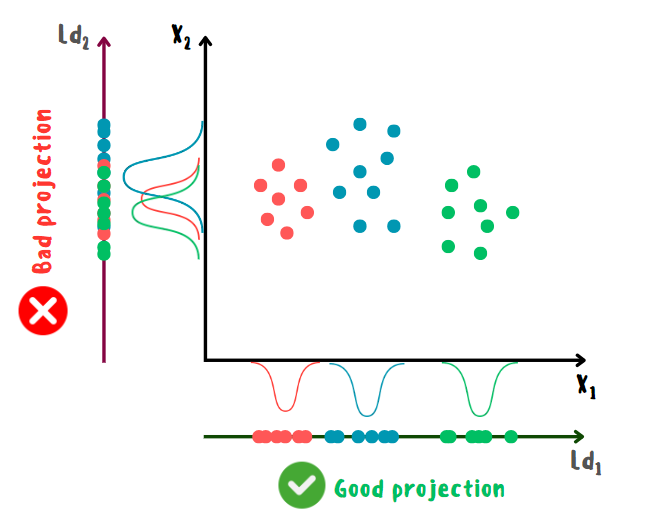

## **Принцип работы LDA**
Алгоритм построен следующим образом:
- 1) изначально для всех классов вычисляются априорные вероятности и средние значения признаков;
- 2) на основе полученных значений вычисляются (ковариационные) матрицы рассеяния между классами и внутри классов;
- 3) далее вычисляются собственные векторы и собственные значения для линейного дискриминанта Фишера, который определяется отношением матриц из шага 2;
- 4) собственные векторы сортируются по убыванию собственных значений и называются *векторами дискриминанта*, которые используются для расчета весов модели;
- 5) на основе полученных весов и априорных вероятностей вычисляется вектор смещения;
- 6) новое пространство признаков меньшей размерности представляет собой линейную комбинацию исходных признаков и векторов дискриминанта и называется *подпространством дискриминанта*;
- 7) предсказанные классы являются максимальной оценкой линейной комбинации тестовой выборки и весов + смещения.

**Формулы для расчетов**

$\mu_k = \frac{1}{n_k} \sum \limits_{i \in C_k} x_i \ - \ $ средние признаки по классу

$\mu = \frac{1}{n} \sum \limits_{i=1}^n x_i \ - \ $ средние признаки

$S_W = \sum \limits_{k=1}^K \sum \limits_{i \in C_k} (x_i - \mu_k)^T (x_i - \mu_k) \ - \ $ внутриклассовая ковариационная матрица

$S_B = \sum \limits_{k=1}^K \pi_k (\mu_k - \mu)^T (\mu_k - \mu) \ - \ $ межклассовая ковариационная матрица

$S_W^{-1} S_B v = \lambda v$

$w = \mu_k d_v d_v^T \ - \ $ веса

$b = \log \pi_k - \frac{1}{2} diag(\mu_k w^T) \ - \ $ смещение

$\delta(x) = argmax(wx + b) \ \ by \ \ class \ - \ $ предсказание

$\lambda - собственные значения, \ \ v - собственные векторы$

$\pi_k \ - \ $ априорная вероятность класса k

$d_v\ - \ $ дискриминантные векторы

## **Более продвинутые методы**
Помимо решения путем поиска собственных векторов, существуют и другие подходы:
- с использованием сингулярного разложения, которое лучше подходит для данных с большим количеством признаков, поскольку ковариационная матрица не рассчитывается;
- решение по наименьшим квадратам, основанное на минимизации среднеквадратичной суммы отклонений классов.

Помимо классического LDA, существуют также модификации на его основе, которые позволяют не только значительно улучшить качество модели, но и увеличить количество задач, в которых ее можно применять. Наиболее популярными модификациями являются следующие:

- **Квадратичный дискриминантный анализ (QDA)** — это обобщение LDA, которое позволяет каждому классу иметь собственную ковариационную матрицу. Это делает границу принятия решений нелинейной и более гибкой, но также требует больше параметров для оценки.

- **Гибкий дискриминантный анализ (FDA)** — это метод, который использует сглаживающие сплайны для построения нелинейных комбинаций признаков. Он может лучше аппроксимировать сложные зависимости между признаками и классами, но также может быть склонен к переобучению.

- **Kernel Discriminant Analysis (KDA)** — это метод отображения объектов данных в пространстве более высокой размерности с использованием трюка ядра (его суть объясняется в алгоритме SVM), где улучшается их линейная разделимость. Он также может улавливать сложные нелинейные зависимости, но требует выбора подходящего ядра и его параметров.

Также стоит отметить, что LDA и его модификации поддерживают регуляризацию через степень сжатия ковариационной матрицы, которая регулируется с помощью параметра сжатия (0 — без сжатия, 1 — полное сокращение). Сжатие ковариационной матрицы подразумевает увеличение ее диагональных элементов и уменьшение недиагональных. Такой подход добавляет штраф к модели за большие значения ее параметров, что в целом повышает устойчивость и снижает риск переобучения. Вы также можете установить значение «shrinkage=auto», которое автоматически определит оптимальный уровень усадки с использованием леммы Ледуа-Вульфа (Ledois-Wolf lemma).

## **Плюсы и минусы LDA**

Плюсы:
- простой и эффективный метод линейной классификации и снижения размерности;
- учитывает различия между классами и внутри классов;
- хорошо работает, когда классы имеют нормальное распределение и одинаковую ковариационную матрицу.

Минусы:
- требуется достаточно данных для каждого класса, чтобы оценить матрицы рассеяния;
- чувствителен к выбросам и нарушению предположений о нормальности и гомоскедастичности;
- может быть неэффективен, когда количество признаков значительно превышает количество объектов.

# **Principal Component Analysis**

## **Определение. Анализ главных компонент**
Анализ главных компонент или PCA — это алгоритм обучения без учителя, используемый для уменьшения размерности и выявления наиболее информативных признаков в данных. Его суть заключается в предположении линейности отношений данных и их проекции на подпространство ортогональных векторов, в котором дисперсия будет максимальной. Такие векторы называются главными компонентами, и они определяют направления наибольшей изменчивости (информативности) данных. Альтернативно, суть PCA можно определить как линейную проекцию, которая минимизирует среднеквадратичное расстояние между исходными точками и их проекциями.

## **Принцип работы PCA**
Изначально матрица признаков обязательно центрируется так, чтобы первая главная компонента могла соответствовать направлению максимальной вариации данных, а не просто их среднему значению. Обычно нахождение главных компонент сводится к двум основным методам:
- **Вычисление собственных векторов и собственных значений ковариационной матрицы данных**. Поскольку ковариационная матрица отражает степень линейной связи между различными переменными, собственные векторы этой матрицы будут задавать направления, вдоль которых дисперсия данных максимальна, а собственные значения будут задавать величину этой дисперсии. Собственное значение, соответствующее собственному вектору, характеризует вклад этого вектора в объяснение дисперсии данных и чем больше собственное значение, тем значимее главная компонента. Обычно выбираются только те главные компоненты, которые объясняют заданный уровень дисперсии, например, 95%.

- **Вычисление сингулярного разложения матрицы данных**. Сингулярное разложение — это способ представления любой матрицы в виде произведения трех других матриц: левой сингулярной матрицы U, диагональной матрицы сингулярных значений S и правой сингулярной матрицы V, где сингулярные значения — это квадратные корни собственных значений ковариационной матрицы данных (именно для этого в данном случае и делается предварительное центрирование данных), правая сингулярная матрица V будет соответствовать собственным векторам ковариационной матрицы данных, а левая U будет проекцией исходных данных на главные компоненты, определяемые матрицей V. Таким образом, сингулярное разложение также позволяет выделить главные компоненты, но без необходимости вычисления ковариационной матрицы. Помимо того, что такое решение более эффективно, оно считается более численно устойчивым, поскольку не требует непосредственного вычисления ковариационной матрицы, которая может быть плохо обусловлена ​​в случае сильной корреляции признаков. В частности, этот подход используется при реализации scikit-learn, но с некоторыми особенностями, обсуждаемыми ниже.

**PCA на основе SVD строится следующим образом:**
- 1) сначала выполняется центрирование данных, и количество компонентов определяется по крайней мере между количеством образцов и признаков, если количество компонентов не указано;
- 2) Затем SVD применяется к центрированной матрице данных;
- 3) к матрице U применяется метод svd_flip_vector, который находит максимальные по модулю элементы в каждом столбце матрицы U, извлекает их знаки и умножает матрицу U на эти знаки, чтобы гарантировать детерминированный вывод;
- 4) объясненная дисперсия для каждого главного компонента вычисляется как квадрат соответствующих сингулярных значений, деленный на n_samples - 1, и преобразованные данные вычисляются с учетом количества главных компонентов в соответствии с правилом $X_{new} = X \cdot V = U \cdot S \cdot V^T \cdot V = U \cdot S$.

## **Дополнительные возможности PCA**
**Коэффициент объясненной дисперсии** каждого основного компонента, доступный через переменную *explained_variance_ratio_*, указывает долю дисперсии набора данных, лежащую вдоль оси каждого основного компонента.

**Восстановление данных** с использованием метода *inverse_transform()* заключается в применении обратного преобразования проекции PCA вида $X_{recovered} = X_{d-proj} W_d^T$, где $W_d^T$ — матрица первых d главных компонентов. Из этого следует, что данные будут восстановлены с потерями, пропорциональными величине отброшенной дисперсии исходных данных, а средний квадрат расстояния между исходными и восстановленными данными представляет собой *ошибку реконструкции*.

**Инкрементальный PCA**, реализованный как класс [*IncrementalPCA*](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.IncrementalPCA), позволяет эффективнее работать с большими наборами данных, разбивая их на мини-пакеты и сохраняя их в памяти по частям во время обучения.

**Рандомизированный PCA**, заданный с помощью параметра svd_solver='randomized', использует стохастический алгоритм для быстрого вычисления приблизительных главных компонент d и основан на предположении, что случайная проекция данных на подпространство с низкой размерностью может хорошо сохранять их структуру и свойства, однако такой подход может быть менее точным.

**Kernel PCA**, реализованный с помощью класса [*KernelPCA*](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.KernelPCA.html), позволяет выполнять сложные нелинейные проекции с использованием функций ядра. Как и в случае SVM, его суть в данном случае заключается в том, что линейная граница решений в многомерном пространстве признаков будет соответствовать сложной нелинейной границе в исходном пространстве.

## **Альтернативы PCA**
Несмотря на то, что метод главных компонент является одним из самых популярных алгоритмов снижения размерности, существуют альтернативы, которые могут быть более предпочтительными в ряде ситуаций, а также в зависимости от типа данных:
- **LLE (Locally Linear Embedding)** — алгоритм создания линейных комбинаций каждой точки из ее соседей с последующим восстановлением этих комбинаций в пространстве меньшей размерности, что позволяет сохранить нелинейную геометрию данных и быть полезным для некоторых задач, где глобальные свойства менее важны. С другой стороны, этот подход имеет высокую вычислительную сложность и может быть чувствителен к шуму.
- **t-SNE (t-Distributed Stochastic Neighbor Embedding)** — алгоритм, который преобразует сходства между данными в вероятности и в дальнейшем пытается минимизировать расхождение между распределениями вероятностей в пространстве большой и малой размерности. t-SNE эффективен для визуализации многомерных данных, но он может исказить глобальную структуру данных, поскольку не учитывает линейные зависимости, а только их близость в исходном пространстве.
- **UMAP (Uniform Manifold Approximation and Projection)** — еще один алгоритм, подходящий для визуализации данных, который основан на идее, что данные лежат на некотором однородном многообразии, которое можно аппроксимировать с помощью соседнего графа. Этот подход учитывает глобальную структуру данных и позволяет лучше адаптироваться к различным типам данных и лучше обрабатывать шум и выбросы, чем t-SNE.
- **Автокодировщики** — это тип нейронных сетей, основанный на обучении кодировщика для преобразования входных данных в низкоразмерное представление с последующим обучением декодера для восстановления исходных данных из этого представления. Автокодировщики также могут использоваться для сжатия данных, удаления шума и многих других целей.

## **Плюсы и минусы**
Плюсы:
- уменьшение размерности при сохранении большого объема информации, что также позволяет визуализировать высокоразмерные данные в двумерном или трехмерном пространстве;
- позволяет не только существенно ускорить обучение, но и уменьшить переобучение моделей в некоторых случаях;
- может использоваться для сжатия данных.

Минусы:
- неизбежная потеря части информации в данных;
- поиск только линейной зависимости в данных (в классическом PCA);
- отсутствие семантического смысла основных компонент из-за сложности их связывания с реальными признаками.

## Отличия между LDA и PCA

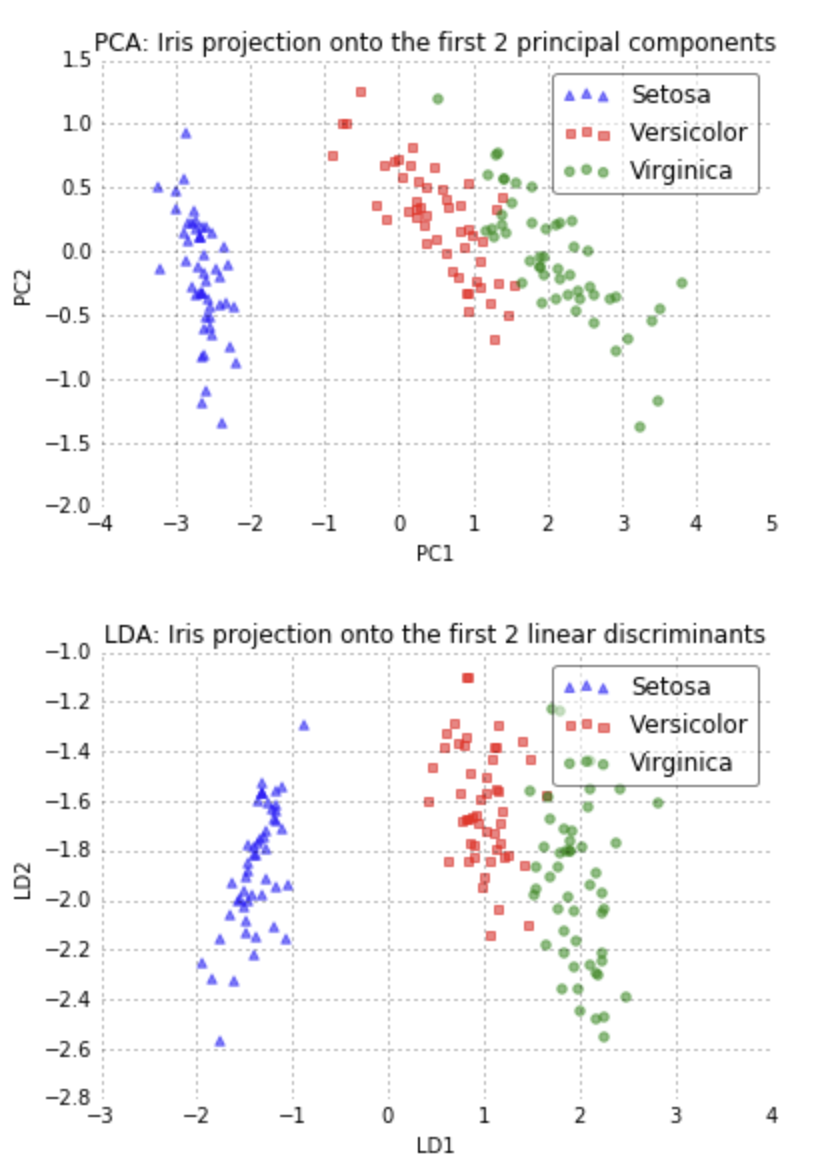

Два графика выше наглядно показывают что, там, где PCA учитывает наибольшую дисперсию во всем наборе данных, LDA дает нам оси, которые учитывают наибольшую дисперсию между отдельными классами.